<a target="_blank" href="https://colab.research.google.com/github/jvictorferreira3301/metodos-numericos/blob/main/M%C3%A9todos_Num%C3%A9ricos_Grupo_3.ipynb"> <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho 1: Raízes de Equações

---

## $I$. Métodos Intervalares

### 1. Varredura de possíveis raízes
* Implementar busca incremental de possíveis raízes num intervalo de interesse, com base na seção 5.4, página 113.
* Receber do usuário a expressão da função, o intervalo de interesse e o número N de subdivisões.
* Calcular o sinal da função para cada subdivisão.
* Retornar os subintervalos com mudança de sinal ou zero da função.
* Retornar gráfico mostrando todas as subdivisões e destacando as detecções de mudança de sinal.
* Solicitar ao usuário se deseja refinar N ou proceder para o cálculo.

MÉTODO 1: VARREDURA DE POSSÍVEIS RAÍZES

1. ENTRADA DE DADOS
------------------------------------------------------------

2. CÁLCULO DAS SUBDIVISÕES
------------------------------------------------------------

Tabela de Subdivisões:
 Ponto    f(x)    Sinal
  -2.0 -24.000 Negativo
  -1.5 -11.875 Negativo
  -1.0  -4.000 Negativo
  -0.5   0.375 Positivo
   0.0   2.000 Positivo
   0.5   1.625 Positivo
   1.0   0.000     Zero
   1.5  -2.125 Negativo
   2.0  -4.000 Negativo
   2.5  -4.875 Negativo
   3.0  -4.000 Negativo
   3.5  -0.625 Negativo
   4.0   6.000 Positivo
   4.5  16.625 Positivo
   5.0  32.000 Positivo

3. DETECÇÃO DE MUDANÇAS DE SINAL
------------------------------------------------------------

Total de possíveis raízes detectadas: 3

Subintervalos com possíveis raízes:
 Inicio  Fim  f(inicio)  f(fim)             Tipo
   -1.0 -0.5     -4.000   0.375 Mudança de Sinal
    1.0  1.0      0.000   0.000  Zero Encontrado
    3.5  4.0     -0.625   6.000 Mudança de Sinal

4. VISUALIZ

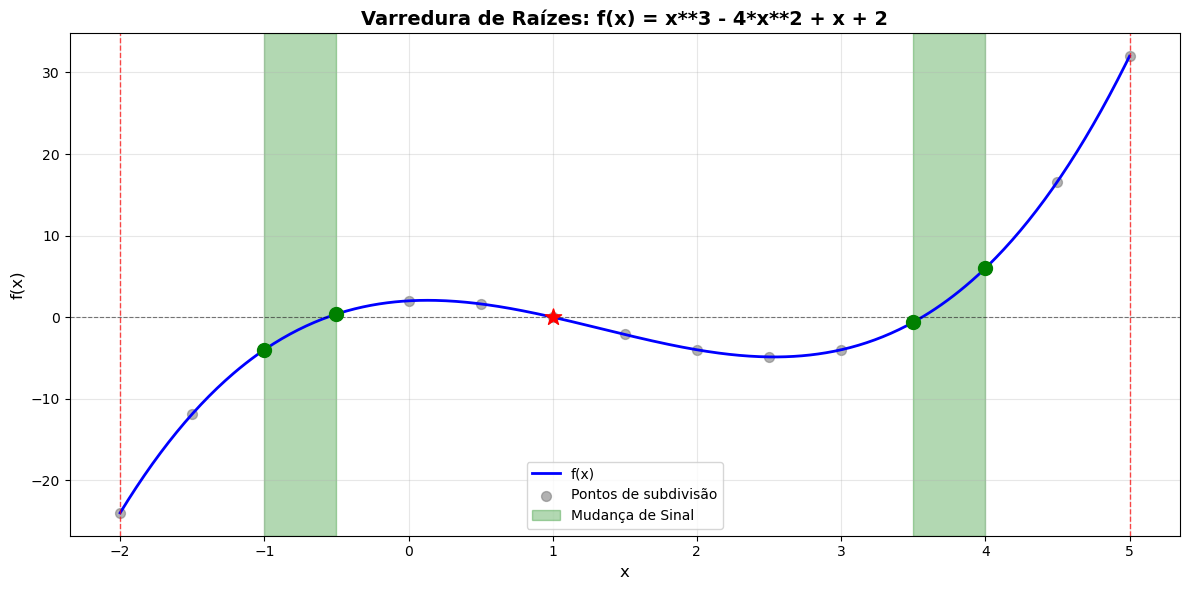


5. REFINAMENTO E PRÓXIMOS PASSOS
------------------------------------------------------------

Opções:
1. Refinar a busca com um novo valor de N
2. Prosseguir para o cálculo de raízes (Método da Bisseção)
3. Sair

Próxima etapa: Execute a próxima célula para calcular raízes com o método da bisseção.
Intervalos disponíveis para cálculo guardados na memória.


'\n# Cenário 1: Polinômio com múltiplas raízes\nx**3 - 4*x**2 + x + 2\n-2\n5\n14\n\n# Cenário 2: Função Trigonométrica\nsin(x) - 0.5\n0\n6\n12\n\n# Cenário 3: Teste de "Zero Exato"\nx**2 - 4\n0\n4\n4\n'

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, lambdify, sympify
import pandas as pd

def busca_incremental_raizes():
    """
    Implementa a busca incremental de possíveis raízes num intervalo.
    Baseado na seção 5.4, página 113.
    Retorna uma tupla: (lista_de_intervalos_detectados, expressao_em_string)
    """
    print("="*60)
    print("MÉTODO 1: VARREDURA DE POSSÍVEIS RAÍZES")
    print("="*60)
    
    # Etapa 1: Receber entrada do usuário
    print("\n1. ENTRADA DE DADOS")
    print("-" * 60)
    
    expr_str = input("Insira a expressão da função f(x): ").strip()
    intervalo_1 = float(input("Insira a primeira extremidade do intervalo: "))
    intervalo_2 = float(input("Insira a segunda extremidade do intervalo: "))
    N = int(input("Insira o número N de subdivisões: "))
    
    # Validar intervalo
    if intervalo_1 > intervalo_2:
        intervalo_1, intervalo_2 = intervalo_2, intervalo_1
    
    # Converter string para função
    x = symbols('x')
    try:
        expr = sympify(expr_str)
        f = lambdify(x, expr, 'numpy')
    except:
        print("Erro: Expressão inválida!")
        return None, None
    
    # Etapa 2: Calcular pontos de subdivisão
    print("\n2. CÁLCULO DAS SUBDIVISÕES")
    print("-" * 60)
    
    pontos = np.linspace(intervalo_1, intervalo_2, N + 1)
    valores_funcao = f(pontos)
    
    # Criar tabela de subdivisões
    dados_subdivisoes = pd.DataFrame({
        'Ponto': pontos,
        'f(x)': valores_funcao,
        'Sinal': ['Positivo' if v > 0 else 'Negativo' if v < 0 else 'Zero' for v in valores_funcao]
    })
    
    print("\nTabela de Subdivisões:")
    print(dados_subdivisoes.to_string(index=False))
    
    # Etapa 3: Detectar mudanças de sinal
    print("\n3. DETECÇÃO DE MUDANÇAS DE SINAL")
    print("-" * 60)
    
    subintervalos_raizes = []
    
    for i in range(len(pontos) - 1):
        if valores_funcao[i] * valores_funcao[i+1] < 0:
            subintervalos_raizes.append({
                'Inicio': pontos[i],
                'Fim': pontos[i+1],
                'f(inicio)': valores_funcao[i],
                'f(fim)': valores_funcao[i+1],
                'Tipo': 'Mudança de Sinal'
            })
        elif valores_funcao[i] == 0:
            subintervalos_raizes.append({
                'Inicio': pontos[i],
                'Fim': pontos[i],
                'f(inicio)': valores_funcao[i],
                'f(fim)': valores_funcao[i],
                'Tipo': 'Zero Encontrado'
            })
    
    if valores_funcao[-1] == 0:
        subintervalos_raizes.append({
            'Inicio': pontos[-1],
            'Fim': pontos[-1],
            'f(inicio)': valores_funcao[-1],
            'f(fim)': valores_funcao[-1],
            'Tipo': 'Zero Encontrado'
        })
    
    print(f"\nTotal de possíveis raízes detectadas: {len(subintervalos_raizes)}")
    
    if subintervalos_raizes:
        df_raizes = pd.DataFrame(subintervalos_raizes)
        print("\nSubintervalos com possíveis raízes:")
        print(df_raizes.to_string(index=False))
    else:
        print("Nenhuma raiz detectada neste intervalo!")
    
    # Etapa 4: Plotar gráfico
    print("\n4. VISUALIZAÇÃO GRÁFICA")
    print("-" * 60)
    
    x_plot = np.linspace(intervalo_1, intervalo_2, 500)
    y_plot = f(x_plot)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(x_plot, y_plot, 'b-', linewidth=2, label='f(x)')
    ax.scatter(pontos, valores_funcao, color='gray', s=50, alpha=0.6, label='Pontos de subdivisão')
    
    for raiz in subintervalos_raizes:
        if raiz['Tipo'] == 'Mudança de Sinal':
            ax.axvspan(raiz['Inicio'], raiz['Fim'], alpha=0.3, color='green', label='Mudança de Sinal' if raiz == subintervalos_raizes[0] else '')
            ax.scatter([raiz['Inicio'], raiz['Fim']], [raiz['f(inicio)'], raiz['f(fim)']], 
                      color='green', s=100, marker='o', zorder=5)
        elif raiz['Tipo'] == 'Zero Encontrado':
            ax.scatter([raiz['Inicio']], [raiz['f(inicio)']], 
                      color='red', s=150, marker='*', zorder=5, label='Zero Encontrado' if raiz == subintervalos_raizes[0] else '')
    
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axvline(x=intervalo_1, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax.axvline(x=intervalo_2, color='red', linestyle='--', linewidth=1, alpha=0.7)
    
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('f(x)', fontsize=12)
    ax.set_title(f'Varredura de Raízes: f(x) = {expr_str}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')
    
    plt.tight_layout()
    plt.show()
    
    # Etapa 5: Oferecer opções de refinamento
    print("\n5. REFINAMENTO E PRÓXIMOS PASSOS")
    print("-" * 60)
    print("\nOpções:")
    print("1. Refinar a busca com um novo valor de N")
    print("2. Prosseguir para o cálculo de raízes (Método da Bisseção)")
    print("3. Sair")
    
    opcao = input("\nEscolha uma opção (1, 2 ou 3): ").strip()
    
    if opcao == '1':
        print("\nRetornando para refinar a busca...")
        return busca_incremental_raizes()
    elif opcao == '2':
        print("\nPróxima etapa: Execute a próxima célula para calcular raízes com o método da bisseção.")
        if subintervalos_raizes:
            print("Intervalos disponíveis para cálculo guardados na memória.")
        return subintervalos_raizes, expr_str
    else:
        print("\nSaída do programa.")
        return None, None

# Executar o programa e salvar as variáveis globalmente
# Desempacotar a tupla gerada na opção 2.
try:
    resultado_varredura, expressao_funcao = busca_incremental_raizes()
except ValueError:
    pass # Tratamento para caso ocorra interrupção inexperada

'''
# Cenário 1: Polinômio com múltiplas raízes
x**3 - 4*x**2 + x + 2
-2
5
14

# Cenário 2: Função Trigonométrica
sin(x) - 0.5
0
6
12

# Cenário 3: Teste de "Zero Exato"
x**2 - 4
0
4
4
'''

### 2. Método da Bisseção
* Implementar rotina para calcular as raízes detectadas na varredura via método da bisseção.
* Receber do usuário o nível de precisão (tolerância).
* Mostrar tabela com resultados de todas as iterações.
* A tabela deve conter: número da iteração, valor da esquerda, valor da direita, ponto médio e valor da função no ponto médio.
* Solicitar ao usuário se deseja repetir o processo para a próxima raiz, caso mais de uma tenha sido detectada.

In [10]:
import numpy as np
import pandas as pd
from sympy import symbols, lambdify, sympify

def metodo_bisseccao(f, a, b, tolerancia, max_iteracoes=100):
    """
    Implementa o método da bisseção para encontrar raízes.
    
    Parâmetros:
    - f: função
    - a, b: extremidades do intervalo
    - tolerancia: critério de convergência
    - max_iteracoes: número máximo de iterações
    
    Retorna:
    - DataFrame com histórico de iterações
    - raiz aproximada
    """
    
    # Validar intervalo
    if f(a) * f(b) > 0:
        print("Erro: A função não muda de sinal no intervalo [a, b]!")
        return None, None
    
    iteracoes = []
    iteracao = 0
    
    # Garantir que a < b
    if a > b:
        a, b = b, a
    
    while (b - a) > tolerancia and iteracao < max_iteracoes:
        c = (a + b) / 2  # Ponto médio
        fc = f(c)
        
        iteracoes.append({
            'Iteração': iteracao + 1,
            'a (Esquerda)': a,
            'b (Direita)': b,
            'c (Ponto Médio)': c,
            'f(c)': fc,
            'Erro Absoluto': (b - a) / 2
        })
        
        # Atualizar intervalo baseado no sinal
        if f(a) * fc < 0:
            b = c  # Raiz está em [a, c]
        else:
            a = c  # Raiz está em [c, b]
        
        iteracao += 1
    
    # Último ponto
    c = (a + b) / 2
    fc = f(c)
    iteracoes.append({
        'Iteração': iteracao + 1,
        'a (Esquerda)': a,
        'b (Direita)': b,
        'c (Ponto Médio)': c,
        'f(c)': fc,
        'Erro Absoluto': (b - a) / 2
    })
    
    df_iteracoes = pd.DataFrame(iteracoes)
    return df_iteracoes, c

def executor_bisseccao(subintervalos_raizes, f_str):
    """
    Executa o método da bisseção para todos os intervalos detectados.
    """
    if not subintervalos_raizes:
        print("\nNenhum intervalo com raiz disponível!")
        return
    
    print("\n" + "="*80)
    print("MÉTODO 2: MÉTODO DA BISSEÇÃO")
    print("="*80)
    
    # Receber tolerância do usuário
    print("\nInserção de Parâmetro:")
    print("-" * 80)
    try:
        tolerancia = float(input("Insira a tolerância (precisão) desejada: "))
        if tolerancia <= 0:
            print("Erro: Tolerância deve ser positiva!")
            return
    except:
        print("Erro: Valor inválido para tolerância!")
        return
    
    # Converter string para função
    x = symbols('x')
    try:
        expr = sympify(f_str)
        f = lambdify(x, expr, 'numpy')
    except:
        print("Erro: Expressão inválida!")
        return
    
    resultados_totais = []
    
    for idx, intervalo in enumerate(subintervalos_raizes, 1):
        print(f"\n{'='*80}")
        print(f"Raiz #{idx} - Intervalo: [{intervalo['Inicio']:.6f}, {intervalo['Fim']:.6f}]")
        print(f"{'='*80}")
        
        a = intervalo['Inicio']
        b = intervalo['Fim']
        
        # Executar bisseção
        df_resultado, raiz_aprox = metodo_bisseccao(f, a, b, tolerancia)
        
        if df_resultado is not None:
            print(f"\nTabela de Iterações:")
            print(df_resultado.to_string(index=False))
            
            print(f"\n{'─'*80}")
            print(f"Resultado Final:")
            print(f"  Raiz Aproximada: {raiz_aprox:.10f}")
            print(f"  f(raiz): {f(raiz_aprox):.2e}")
            print(f"  Número de Iterações: {len(df_resultado) - 1}")
            print(f"  Erro Absoluto Final: {(b - a) / 2:.2e}")
            print(f"{'─'*80}")
            
            resultados_totais.append({
                'Raiz #': idx,
                'Raiz Aproximada': raiz_aprox,
                'f(raiz)': f(raiz_aprox),
                'Iterações': len(df_resultado) - 1,
                'Tolerância': tolerancia
            })
            
            # Perguntar se deseja continuar para próxima raiz
            if idx < len(subintervalos_raizes):
                continuar = input("\nDeseja continuar para a próxima raiz? (s/n): ").strip().lower()
                if continuar != 's':
                    print("\nExecução interrompida pelo usuário.")
                    break
        else:
            print(f"Não foi possível calcular a raiz neste intervalo.")
    
    # Resumo final
    if resultados_totais:
        print(f"\n{'='*80}")
        print("RESUMO DE TODAS AS RAÍZES CALCULADAS")
        print(f"{'='*80}")
        df_resumo = pd.DataFrame(resultados_totais)
        print(df_resumo.to_string(index=False))
        print(f"{'='*80}\n")
    
    return resultados_totais

# =====================================================================
# EXECUÇÃO PROCEDURAL DO MÉTODO DA BISSEÇÃO
# =====================================================================
# Verifica se a varredura foi executada e as variáveis estão salvas no Notebook
if 'resultado_varredura' in locals() and resultado_varredura is not None:
    resultados_bisseccao = executor_bisseccao(resultado_varredura, expressao_funcao)
else:
    print("Aviso: Variáveis da varredura não encontradas.")
    print("Por favor, execute a célula 'Varredura de possíveis raízes' PRIMEIRO e escolha a OPÇÃO 2.")


MÉTODO 2: MÉTODO DA BISSEÇÃO

Inserção de Parâmetro:
--------------------------------------------------------------------------------

Raiz #1 - Intervalo: [-1.000000, -0.500000]

Tabela de Iterações:
 Iteração  a (Esquerda)  b (Direita)  c (Ponto Médio)      f(c)  Erro Absoluto
        1       -1.0000    -0.500000        -0.750000 -1.421875       0.250000
        2       -0.7500    -0.500000        -0.625000 -0.431641       0.125000
        3       -0.6250    -0.500000        -0.562500 -0.006104       0.062500
        4       -0.5625    -0.500000        -0.531250  0.189911       0.031250
        5       -0.5625    -0.531250        -0.546875  0.093281       0.015625
        6       -0.5625    -0.546875        -0.554688  0.043934       0.007812
        7       -0.5625    -0.554688        -0.558594  0.019002       0.003906
        8       -0.5625    -0.558594        -0.560547  0.006471       0.001953
        9       -0.5625    -0.560547        -0.561523  0.000189       0.000977
       1

### 3. Método da Falsa posição
* Implementar rotina semelhante à da bisseção, aplicando o método da falsa posição.

In [ ]:
# [Célula de Código: Inserir função da falsa posição]

### 4. Comparação entre os métodos
* Implementar comparação gráfica entre bisseção e falsa posição.
* Mostrar graficamente que o método da falsa posição converge mais rápido, semelhante à figura 5.13 da página 110.

In [ ]:
# [Célula de Código: Inserir lógica de sobreposição gráfica e comparação]

### 5. Método da Falsa posição modificado
* Implementar rotina aplicando o método da falsa posição modificado, conforme página 112.

In [ ]:
# [Célula de Código: Inserir função da falsa posição modificada]

### 6. Integração entre os métodos
* Implementar rotina que recebe intervalos de interesse da varredura.
* Calcular raízes usando bisseção, falsa posição e falsa posição modificado.
* Construir uma tabela por raiz por método com todas as iterações.
* Imprimir mensagem informando qual método precisou de menos iterações para cada raiz.

In [ ]:
# [Célula de Código: Inserir orquestrador dos métodos e tabelas comparativas]

### 7. Testes de consistência
* Mostrar exemplos do funcionamento dos códigos com funções elementares definidas pelo grupo.

In [ ]:
# [Célula de Código: Inserir testes com funções básicas]

### 8. Resolução de exercícios (Parte I)
* Resolver os problemas 5.1, 5.2, 5.3, 5.4, 5.5 e 5.13 da página 114 utilizando os programas desenvolvidos.

In [ ]:
# [Células de Código: Inserir resolução de cada problema]

---

## $II$. Métodos Abertos

### 9. Método da iteração de ponto fixo simples
* Implementar rotina que calcule raízes pelo método de ponto fixo simples.
* Receber expressão, chute inicial e tolerância.
* Plotar o gráfico da função.
* Construir tabela exibindo número da iteração, novo x_i e valor da função em x_i.
* Construir gráfico mostrando a convergência ou divergência, conforme Figura 6.3 da página 119.
* Incluir limitador interno de iterações não controlado pelo usuário.
* Implementar acompanhamento interativo das iterações, como um controle deslizante.
* Alertar com exemplo caso o método esteja divergindo.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sympy import symbols, lambdify, sympify
import ipywidgets as widgets
from IPython.display import display

def metodo_ponto_fixo():
    """
    Implementa o método da iteração de ponto fixo simples.
    Requisitos 9.1, 9.2, 9.3 e 9.4.
    """
    print("="*80)
    print("9. MÉTODO DA ITERAÇÃO DE PONTO FIXO SIMPLES")
    print("="*80)
    
    # 9.1: Entrada de dados
    expr_str = input("Insira a expressão da função iterativa g(x) (onde x = g(x)): ").strip()
    try:
        x0 = float(input("Insira o valor do chute inicial (x0): "))
        tolerancia = float(input("Insira a tolerância desejada: "))
    except ValueError:
        print("Erro: Por favor, insira valores numéricos válidos para chute e tolerância!")
        return

    # Converter expressão SymPy
    x_sym = symbols('x')
    try:
        expr = sympify(expr_str)
        g = lambdify(x_sym, expr, 'numpy')
    except Exception as e:
        print(f"Erro ao avaliar a expressão: {e}")
        return

    # 9.3: Limitador interno de iterações (não controlado pelo usuário)
    max_iteracoes = 50 
    
    iteracoes_x = [x0]
    iteracoes_g = [g(x0)]
    
    x_atual = x0
    divergiu = False
    
    for i in range(1, max_iteracoes + 1):
        try:
            x_novo = g(x_atual)
        except Exception:
            # Captura overflow numérico
            divergiu = True
            break
            
        iteracoes_x.append(x_novo)
        iteracoes_g.append(g(x_novo))
        
        # Verificação pragmática de divergência (valores absurdamente altos)
        if abs(x_novo) > 1e10:
            divergiu = True
            break
            
        # Condição de parada de convergência
        if abs(x_novo - x_atual) < tolerancia:
            break
            
        x_atual = x_novo

    # 9.1: Construção da Tabela com saídas
    df_iteracoes = pd.DataFrame({
        'Iteração': range(len(iteracoes_x)),
        'x_i (novo valor)': iteracoes_x,
        'g(x_i) (função)': iteracoes_g
    })
    
    print("\nTabela de Iterações:")
    print("-" * 80)
    print(df_iteracoes.to_string(index=False))
    print("-" * 80)
    
    # Alertar caso o método esteja divergindo
    if divergiu or len(iteracoes_x) > max_iteracoes:
        print("\nALERTA: O método está divergindo ou não atingiu convergência dentro do limite interno!")
        print("Exemplo: A derivada de g(x) possivelmente possui módulo maior que 1 na proximidade da raiz.")
    else:
        print(f"\n✓ Convergência atingida! Raiz aproximada: {iteracoes_x[-1]:.6f}")

    # 9.2 e 9.4: Gráficos e acompanhamento interativo (Controle Deslizante)
    print("\nAcompanhamento Interativo das Iterações (Figura da Teoria)")
    
    def plot_iteracoes(passo):
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Determinar limites para que o plot não quebre em divergências totais
        historico_valido = [v for v in iteracoes_x[:passo+1] if abs(v) < 1e5]
        if not historico_valido:
            print("Valores divergentes demais para plotar!")
            return
            
        x_min = min(historico_valido) - 2
        x_max = max(historico_valido) + 2
        
        x_vals = np.linspace(x_min, x_max, 400)
        
        # Plotar y = x e y = g(x)
        ax.plot(x_vals, x_vals, 'k--', label='y = x', alpha=0.7)
        try:
            ax.plot(x_vals, g(x_vals), 'b-', label=f'y = g(x) = {expr_str}', linewidth=2)
        except:
            print("Erro ao exibir g(x) para os limites estabelecidos.")
            
        # Desenhar o caminho das iterações: linhas verticais e horizontais (Cobweb plot)
        for i in range(passo):
            x_i = iteracoes_x[i]
            x_next = iteracoes_x[i+1]
            
            # Subir/Descer do y=x até a curva g(x)
            ax.plot([x_i, x_i], [x_i, g(x_i)], 'r-', alpha=0.6)
            # Ir horizontalmente da curva g(x) até y=x para formar x_next
            ax.plot([x_i, x_next], [g(x_i), x_next], 'g--', alpha=0.6)
            
            ax.plot(x_i, g(x_i), 'ro', markersize=4)
            
        # Ponto atual destacado
        ax.plot(iteracoes_x[passo], iteracoes_x[passo], 'yo', markersize=8, label=f'x_{passo} atual')
        if passo < len(iteracoes_x) - 1:
            ax.plot(iteracoes_x[passo], g(iteracoes_x[passo]), 'ro', markersize=6)
            
        ax.set_title("Método do Ponto Fixo Simples - Análise de Convergência/Divergência", fontsize=14)
        ax.set_xlabel('x', fontsize=12)
        ax.set_ylabel('y', fontsize=12)
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.legend()
        plt.tight_layout()
        plt.show()

    # Widget interativo
    slider = widgets.IntSlider(min=0, max=len(iteracoes_x)-1, step=1, value=0, description='Iteração:')
    widgets.interact(plot_iteracoes, passo=slider)

'''
Cenário 1: A Convergência Clássica ("Degraus")
cos(x)
0.5
0.001

Cenário 2: A Convergência Explosiva
x**2 - 2
2.1
0.001

Cenário 3: Convergência em Espiral (Exponencial)
exp(-x)
0
0.001
'''

# Para executar o método, descomente a linha abaixo na hora de testar a célula:
metodo_ponto_fixo()

9. MÉTODO DA ITERAÇÃO DE PONTO FIXO SIMPLES

Tabela de Iterações:
--------------------------------------------------------------------------------
 Iteração  x_i (novo valor)  g(x_i) (função)
        0          0.000000         1.000000
        1          1.000000         0.367879
        2          0.367879         0.692201
        3          0.692201         0.500474
        4          0.500474         0.606244
        5          0.606244         0.545396
        6          0.545396         0.579612
        7          0.579612         0.560115
        8          0.560115         0.571143
        9          0.571143         0.564879
       10          0.564879         0.568429
       11          0.568429         0.566415
       12          0.566415         0.567557
       13          0.567557         0.566909
       14          0.566909         0.567276
--------------------------------------------------------------------------------

✓ Convergência atingida! Raiz aproximada: 0.566909


interactive(children=(IntSlider(value=0, description='Iteração:', max=14), Output()), _dom_classes=('widget-in…

### 10. Método de Newton-Raphson
* Implementar rotina do método de Newton-Raphson.
* Receber expressão, x_0 e tolerância.
* Plotar gráfico da função e tabela de saídas (iteração, novo x_i, função em x_i).
* Plotar gráfico da função junto com a reta tangente de cada iteração.
* Calcular a derivada da função pelo próprio programa.
* Suspender processo e alertar caso a derivada seja nula em alguma iteração.
* Alertar o usuário sobre possível baixa eficiência se a inclinação estiver abaixo de um limiar.
* Incluir limitador interno de iterações.
* Implementar acompanhamento gráfico interativo das iterações.

In [ ]:
# [Célula de Código: Inserir método numérico, cálculo simbólico/numérico de derivada, plotagem das tangentes e controles interativos]

### 11. Métodos da Secante (Normal e Modificado)
* Implementar métodos da secante normal e modificado.
* Receber expressão, x_0, x_1 e tolerância.
* Plotar gráfico da função e tabela de iterações.
* Construir gráfico exibindo a função e a reta secante de cada iteração.
* Incluir limitador interno de iterações.
* Alertar sobre inclinação nula (suspendendo o processo) ou próxima de zero.

In [ ]:
# [Célula de Código: Inserir métodos da secante e plotagem das retas secantes]

### 12. Integração e Resolução de Exercícios (Parte II)
* Integrar as rotinas e resolver os problemas 6.2, 6.5, 6.10 e 6.24 das páginas 136 e 137.

In [ ]:
# [Células de Código: Inserir execução integrada e respostas dos exercícios]

---

## $III$. Raízes de Polinômios

### 13. Métodos de Müller e de Bairstow
* Implementar métodos de Müller e Bairstow baseados nas seções 7.4 e 7.5, páginas 144 e 147.
* Resolver os exemplos do livro correspondentes a essas seções com o programa.

In [ ]:
# [Célula de Código: Inserir implementação dos métodos polinomiais e validação com exemplos do livro]

### 14. Resolução de exercícios (Parte III)
* Resolver os itens dos problemas 7.2, 7.3, 7.4 e 7.5 da página 160.

In [ ]:
# [Células de Código: Inserir resolução de cada problema]